<a href="https://colab.research.google.com/github/wyogifirdaus-sudo/asik_deh/blob/main/MP02_Wisnu_Yogi_Firdaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA SET


https://www.kaggle.com/code/ifeanyies/ds-salaries


In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
import pandas as pd

df = pd.read_csv('/content/ds_salaries.csv')
df

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


# **Pengecekan Awal**

In [64]:
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.isna().sum()

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [67]:
df.drop(columns=['Unnamed: 0', 'salary', 'salary_currency', 'work_year'], axis=1, inplace=True)

In [68]:
df.head()

,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,MI,FT,Data Scientist,79833,DE,0,DE,L
1,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,SE,FT,Machine Learning Engineer,150000,US,50,US,L


# **EDA**

In [69]:
df.describe()

,salary_in_usd,remote_ratio
count,607.000000,607.00000
mean,112297.869852,70.92257
std,70957.259411,40.70913
min,2859.000000,0.00000
25%,62726.000000,50.00000
50%,101570.000000,100.00000
75%,150000.000000,100.00000
max,600000.000000,100.00000


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   experience_level    607 non-null    object
 1   employment_type     607 non-null    object
 2   job_title           607 non-null    object
 3   salary_in_usd       607 non-null    int64 
 4   employee_residence  607 non-null    object
 5   remote_ratio        607 non-null    int64 
 6   company_location    607 non-null    object
 7   company_size        607 non-null    object
dtypes: int64(2), object(6)
memory usage: 38.1+ KB


In [71]:
df.shape

(607, 8)

In [72]:
list_columns = df.columns
list_columns

Index(['experience_level', 'employment_type', 'job_title', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [73]:
df['company_size'] = df['company_size'].map({'S': 1, 'M': 2, 'L': 3})

In [74]:
df['employment_type']= df['employment_type'].map({'FT': 1, 'CT': 2, 'PT': 3, 'FL': 4})

experience_level_mapping = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
df['experience_level'] = df['experience_level'].replace(experience_level_mapping)

df['remote_ratio'] = df['remote_ratio'].map({0: 0, 50: 1, 100: 2})

# Convert 'salary_in_usd' to a binary classification problem
average_salary = df['salary_in_usd'].mean()
df['salary_in_usd'] = (df['salary_in_usd'] > average_salary).astype(int)

df.head()

/tmp/ipykernel_3231/3544909610.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience_level'] = df['experience_level'].replace(experience_level_mapping)


,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2,1,Data Scientist,0,DE,0,DE,3
1,3,1,Machine Learning Scientist,1,JP,0,JP,1
2,3,1,Big Data Engineer,0,GB,1,GB,2
3,2,1,Product Data Analyst,0,HN,0,HN,1
4,3,1,Machine Learning Engineer,1,US,1,US,3


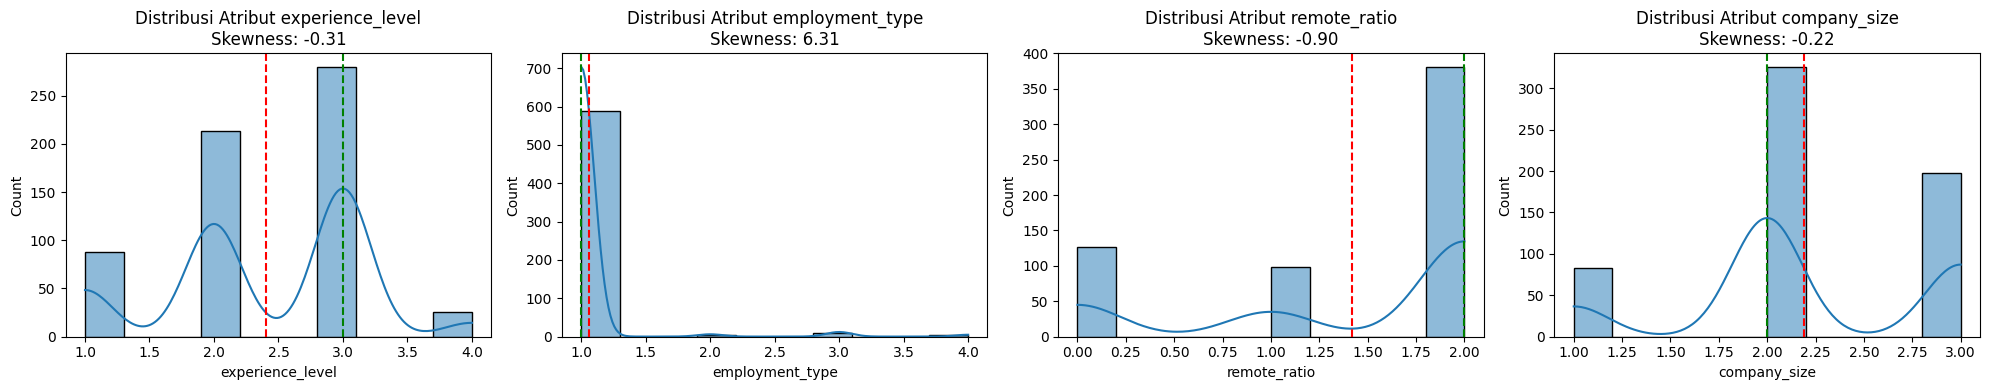

In [75]:
list_numeric= ['experience_level', 'employment_type', 'remote_ratio', 'company_size']
fig,ax= plt.subplots(1, len(list_numeric), figsize=(20,4))

for i,col in enumerate(list_numeric):
    sns.histplot(data=df, x=col, ax=ax[i], kde=True, bins=10)
    ax[i].axvline(df[col].mean(), color='r', linestyle='--')
    ax[i].axvline(df[col].median(), color='g', linestyle='--')
    ax[i].set_title(f'Distribusi Atribut {col}\nSkewness: {df[col].skew():.2f}')

plt.tight_layout() # Added to prevent labels from overlapping
plt.show()

In [76]:
import scipy.stats as stats

corr_r, pval_p = stats.pearsonr(df['experience_level'], df['salary_in_usd'])
corr_rho, pval_s = stats.spearmanr(df['experience_level'], df['salary_in_usd'])
corr_tau, pval_k = stats.kendalltau(df['experience_level'], df['salary_in_usd'])

print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")
print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")
print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")


corr_r, pval_p = stats.pearsonr(df['employment_type'], df['salary_in_usd'])
corr_rho, pval_s = stats.spearmanr(df['employment_type'], df['salary_in_usd'])
corr_tau, pval_k = stats.kendalltau(df['employment_type'], df['salary_in_usd'])

print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")
print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")
print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")

corr_r, pval_p = stats.pearsonr(df['company_size'], df['salary_in_usd'])
corr_rho, pval_s = stats.spearmanr(df['company_size'], df['salary_in_usd'])
corr_tau, pval_k = stats.kendalltau(df['company_size'], df['salary_in_usd'])

print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")
print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")
print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")

corr_r, pval_p = stats.pearsonr(df['remote_ratio'], df['salary_in_usd'])
corr_rho, pval_s = stats.spearmanr(df['remote_ratio'], df['salary_in_usd'])
corr_tau, pval_k = stats.kendalltau(df['remote_ratio'], df['salary_in_usd'])

print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")
print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")
print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")

r-correlation: 0.48, p-value: 3.494148934635396e-36
rho-correlation: 0.49, p-value: 1.778231743816103e-38
tau-correlation: 0.46, p-value: 6.984065015659872e-34
r-correlation: -0.13, p-value: 0.0010144941809088917
rho-correlation: -0.12, p-value: 0.002267922811951656
tau-correlation: -0.12, p-value: 0.002328804624420632
r-correlation: 0.09, p-value: 0.025707885029514058
rho-correlation: 0.07, p-value: 0.06729310045155253
tau-correlation: 0.07, p-value: 0.06733283178034097
r-correlation: 0.13, p-value: 0.0008895588897600912
rho-correlation: 0.16, p-value: 6.198047050047372e-05
tau-correlation: 0.16, p-value: 6.786590996691504e-05


In [77]:
df[['experience_level', 'employment_type', 'remote_ratio', 'company_size', 'salary_in_usd']].corr()['salary_in_usd']

,salary_in_usd
experience_level,0.479265
employment_type,-0.133075
remote_ratio,0.134552
company_size,0.090538
salary_in_usd,1.000000


In [78]:
# Splitting antara 'X' dan "y"

X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd'] #target

In [79]:
q1 = df['salary_in_usd'].quantile(0.25)
q3 = df['salary_in_usd'].quantile(0.75)
iqr = q3-q1

up_bound = q3 + 1.5*iqr
low_bound = q1 - 1.5*iqr

print(f'Upper Boundary: {up_bound:.2f}' )
print(f'Lower Boundary: {low_bound:.2f}')

Upper Boundary: 2.50
Lower Boundary: -1.50


In [80]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("### Outlier Detection for All Numeric Features (Tukey's Fences) ###")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nFeature: '{col}'")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of Outliers: {len(outliers)}")
    if len(outliers) > 0:
        print("  Outlier Values:")
        print(outliers[[col]].head())
    print(f'Percentage of outliers: {len(outliers)*100/len(df["salary_in_usd"]):.2f}%%')


### Outlier Detection for All Numeric Features (Tukey's Fences) ###

Feature: 'experience_level'
  Q1: 2.00
  Q3: 3.00
  IQR: 1.00
  Lower Bound: 0.50
  Upper Bound: 4.50
  Number of Outliers: 0
Percentage of outliers: 0.00%%

Feature: 'employment_type'
  Q1: 1.00
  Q3: 1.00
  IQR: 0.00
  Lower Bound: 1.00
  Upper Bound: 1.00
  Number of Outliers: 19
  Outlier Values:
    employment_type
28                2
45                3
54                4
62                3
77                3
Percentage of outliers: 3.13%%

Feature: 'salary_in_usd'
  Q1: 0.00
  Q3: 1.00
  IQR: 1.00
  Lower Bound: -1.50
  Upper Bound: 2.50
  Number of Outliers: 0
Percentage of outliers: 0.00%%

Feature: 'remote_ratio'
  Q1: 1.00
  Q3: 2.00
  IQR: 1.00
  Lower Bound: -0.50
  Upper Bound: 3.50
  Number of Outliers: 0
Percentage of outliers: 0.00%%

Feature: 'company_size'
  Q1: 2.00
  Q3: 3.00
  IQR: 1.00
  Lower Bound: 0.50
  Upper Bound: 4.50
  Number of Outliers: 0
Percentage of outliers: 0.00%%


In [81]:
def handle_outliers(df, col, method='cap'):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  if method == 'trim':
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
  elif method == 'cap':
    df_clean = df.copy()
    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
    return df_clean
  elif method == 'median_impute':
    df_clean = df.copy()
    df_clean[col] = df_clean[col].apply(lambda x: upper_bound if x > upper_bound else x)
    df_clean[col] = df_clean[col].apply(lambda x: lower_bound if x < lower_bound else x)
    return df_clean

In [82]:
# Bandingkan statistik sebelum dan sesudah handling
print("Statistik awal - data skewed:")
print(df['salary_in_usd'].describe())

df_clean_cap = handle_outliers(df, 'salary_in_usd', method='cap')
print("\nStatistik setelah capping:")
print(df_clean_cap['salary_in_usd'].describe())

df_clean_imputed = handle_outliers(df, 'salary_in_usd', method='median_impute')
print("\nStatistik setelah median imputation:")
print(df_clean_imputed['salary_in_usd'].describe())

Statistik awal - data skewed:
count    607.000000
mean       0.444811
std        0.497355
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: salary_in_usd, dtype: float64

Statistik setelah capping:
count    607.000000
mean       0.444811
std        0.497355
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: salary_in_usd, dtype: float64

Statistik setelah median imputation:
count    607.000000
mean       0.444811
std        0.497355
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: salary_in_usd, dtype: float64


In [83]:
df= handle_outliers(df, 'salary_in_usd', method='cap')

In [84]:
X= df.drop('salary_in_usd', axis=1)
y= df['salary_in_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

In [85]:
print('Train size : ', X_train.shape)
print('Test size  : ', X_test.shape)

Train size :  (424, 7)
Test size  :  (183, 7)


In [86]:
# Feature Scaling

# Identify categorical columns in X_train
categorical_cols_train = X_train.select_dtypes(include=['object']).columns

# If there are categorical columns, apply OneHotEncoder
if not categorical_cols_train.empty:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit and transform on X_train
    X_train_encoded_array = ohe.fit_transform(X_train[categorical_cols_train])
    X_train_encoded_df = pd.DataFrame(X_train_encoded_array, columns=ohe.get_feature_names_out(categorical_cols_train), index=X_train.index)

    # Drop original categorical columns and concatenate encoded ones
    X_train_numeric = X_train.drop(columns=categorical_cols_train)
    X_train_processed = pd.concat([X_train_numeric, X_train_encoded_df], axis=1)

    # Transform X_test using the fitted encoder
    X_test_encoded_array = ohe.transform(X_test[categorical_cols_train])
    X_test_encoded_df = pd.DataFrame(X_test_encoded_array, columns=ohe.get_feature_names_out(categorical_cols_train), index=X_test.index)

    # Drop original categorical columns and concatenate encoded ones
    X_test_numeric = X_test.drop(columns=categorical_cols_train)
    X_test_processed = pd.concat([X_test_numeric, X_test_encoded_df], axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()


scaler = StandardScaler()
scaler.fit(X_train_processed)

X_train_scaled = scaler.transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

X_train_scaled

array([[-0.49245827, -0.16886676,  0.71529134, ..., -0.04862166,
        -0.04862166,  0.82212489],
       [ 0.75785495, -0.16886676,  0.71529134, ..., -0.04862166,
        -0.04862166,  0.82212489],
       [-0.49245827, -0.16886676,  0.71529134, ..., -0.04862166,
        -0.04862166, -1.21636021],
       ...,
       [-1.7427715 , -0.16886676,  0.71529134, ..., -0.04862166,
        -0.04862166,  0.82212489],
       [-0.49245827, -0.16886676,  0.71529134, ..., -0.04862166,
        -0.04862166, -1.21636021],
       [-0.49245827, -0.16886676, -0.49300957, ..., -0.04862166,
        -0.04862166,  0.82212489]])

In [87]:
# Splitting between Train-Set, Val-Set, and Test-Set

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42)

print('Train Size : ', X_train.shape)
print('Val Size   : ', X_val.shape)
print('Test Size  : ', X_test.shape)

Train Size :  (437, 7)
Val Size   :  (78, 7)
Test Size  :  (92, 7)


In [88]:
# Check Missing Values on X_train

X_train.isnull().sum()

,0
experience_level,0
employment_type,0
job_title,0
employee_residence,0
remote_ratio,0
company_location,0
company_size,0


In [89]:
# Check Missing Values on X_val

X_val.isnull().sum()

,0
experience_level,0
employment_type,0
job_title,0
employee_residence,0
remote_ratio,0
company_location,0
company_size,0


In [90]:
# Check Missing Values on X_test

X_test.isnull().sum()

,0
experience_level,0
employment_type,0
job_title,0
employee_residence,0
remote_ratio,0
company_location,0
company_size,0


In [91]:
# Get Numerical Columns and Categorical Columns

num_columns = X_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = X_train.select_dtypes(include=['object']).columns.tolist()

# Dynamically get column indices for robustness, ensuring X_train is a DataFrame here
num_indices = [X_train.columns.get_loc(col) for col in num_columns]
cat_indices = [X_train.columns.get_loc(col) for col in cat_columns]

print('Numerical Columns : ', num_columns)
print('Categorical Columns : ', cat_columns)

Numerical Columns :  ['experience_level', 'employment_type', 'remote_ratio', 'company_size']
Categorical Columns :  ['job_title', 'employee_residence', 'company_location']


In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report

# Create A Pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy='median'),
                             StandardScaler())

# Fix: Add handle_unknown='ignore' and sparse_output=False to OneHotEncoder
cat_pipeline = make_pipeline(OneHotEncoder(handle_unknown='ignore', sparse_output=False))

# Fix: Use integer indices instead of string names for column selection
final_pipeline = ColumnTransformer([
    ('pipe_num', num_pipeline, num_indices),
    ('pipe_cat', cat_pipeline, cat_indices)
])

In [93]:
# Fit and Transform

X_train = final_pipeline.fit_transform(X_train)
X_val = final_pipeline.transform(X_val)
X_test = final_pipeline.transform(X_test)
X_train.shape

(437, 135)

In [94]:
# Clear session

import tensorflow as tf

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

# Check TensorFlow version
print(tf.__version__)

2.20.0


In [95]:
# Create Sequential API

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.initializers import HeNormal


model_sequential = Sequential()
model_sequential.add(Dense(16,
                           activation='relu',
                           kernel_initializer=tf.keras.initializers.HeNormal(seed),
                           input_shape=(135,)))
model_sequential.add(Dropout(0.2))
model_sequential.add(Dense(8,
                           activation='relu',
                           kernel_initializer=tf.keras.initializers.HeNormal(seed)))
model_sequential.add(Dropout(0.2))
model_sequential.add(Dense(1,
                           activation='sigmoid',
                           kernel_initializer=tf.keras.initializers.GlorotNormal(seed)))

model_sequential.compile(loss='binary_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])
model_sequential.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,321 (9.07 KB)

 Trainable params: 2,321 (9.07 KB)

 Non-trainable params: 0 (0.00 B)

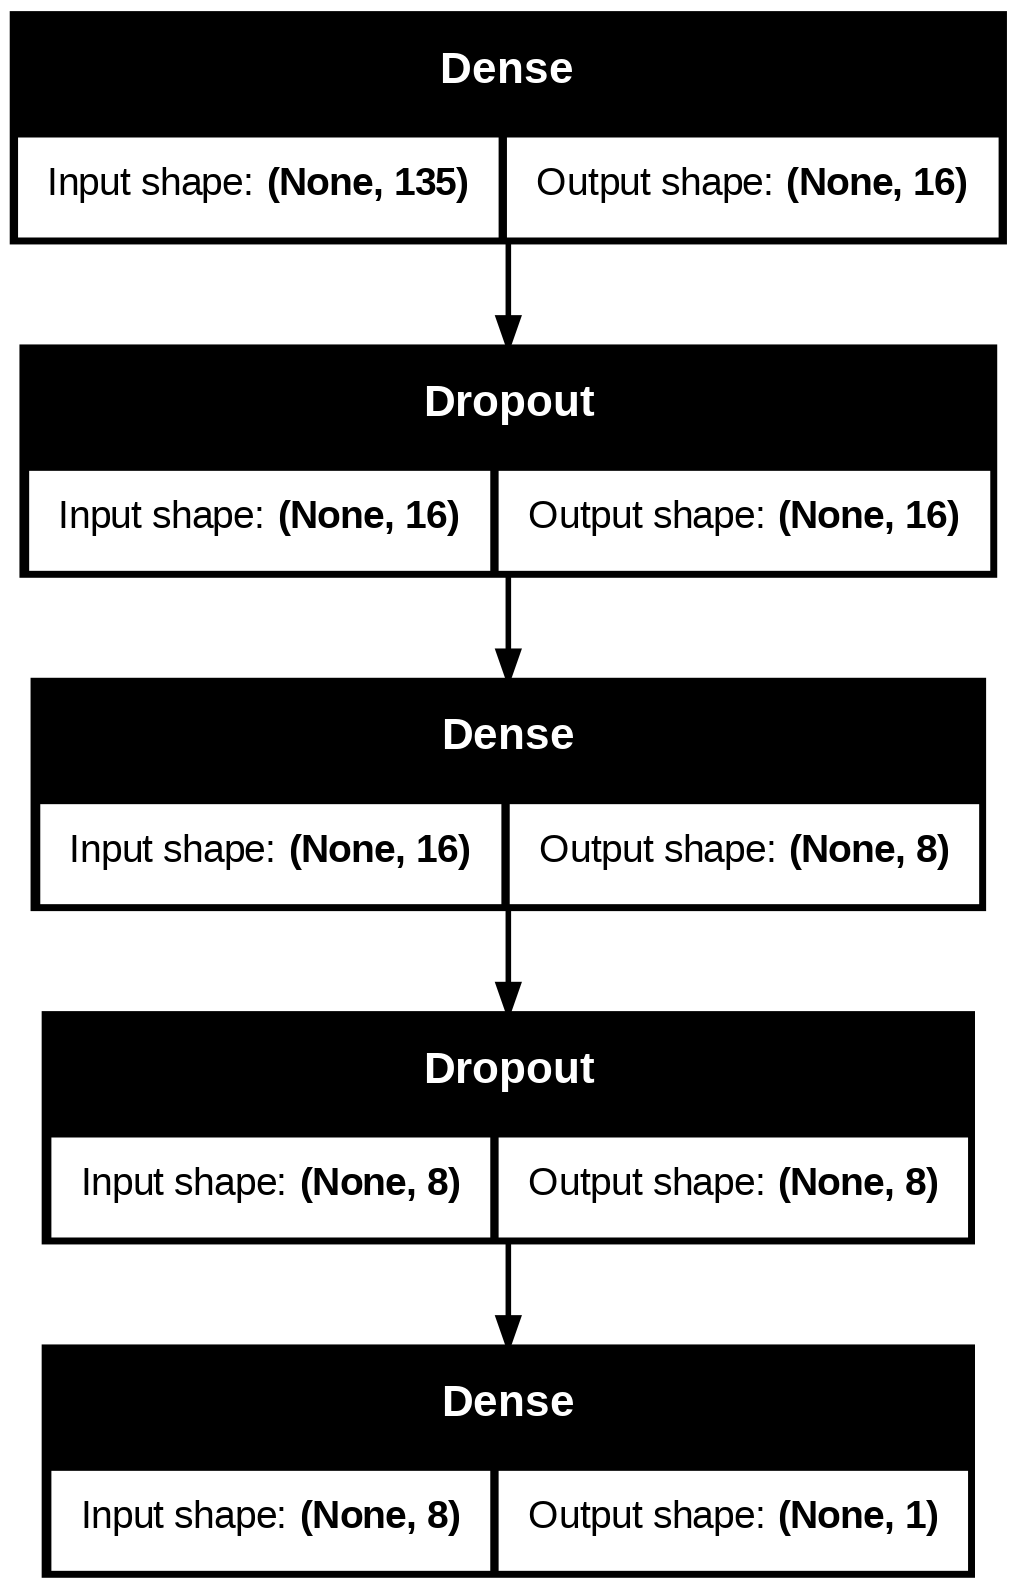

In [96]:
# Plot layers

tf.keras.utils.plot_model(model_sequential, show_shapes=True)

In [97]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True)

In [98]:
# Train the model

%%time

history_sequential = model_sequential.fit(X_train,
                                          y_train,
                                          epochs=20,
                                          validation_data=(X_val, y_val),
                                          batch_size=10)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4691 - loss: 0.7291 - val_accuracy: 0.5256 - val_loss: 0.7043
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5011 - loss: 0.7099 - val_accuracy: 0.6923 - val_loss: 0.6897
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6270 - loss: 0.6834 - val_accuracy: 0.7564 - val_loss: 0.6753
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6430 - loss: 0.6684 - val_accuracy: 0.7564 - val_loss: 0.6571
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7208 - loss: 0.6377 - val_accuracy: 0.7821 - val_loss: 0.6266
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7506 - loss: 0.6041 - val_accuracy: 0.7949 - val_loss: 0.5820
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7803 - loss: 0.5651 - val_accuracy: 0.8077 - val_loss: 0.5386
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7895 - loss: 0.5443 - val_accuracy: 0.8205 - val_loss:

Text(0.5, 1.0, 'Grafik Acc vs Val-Acc')

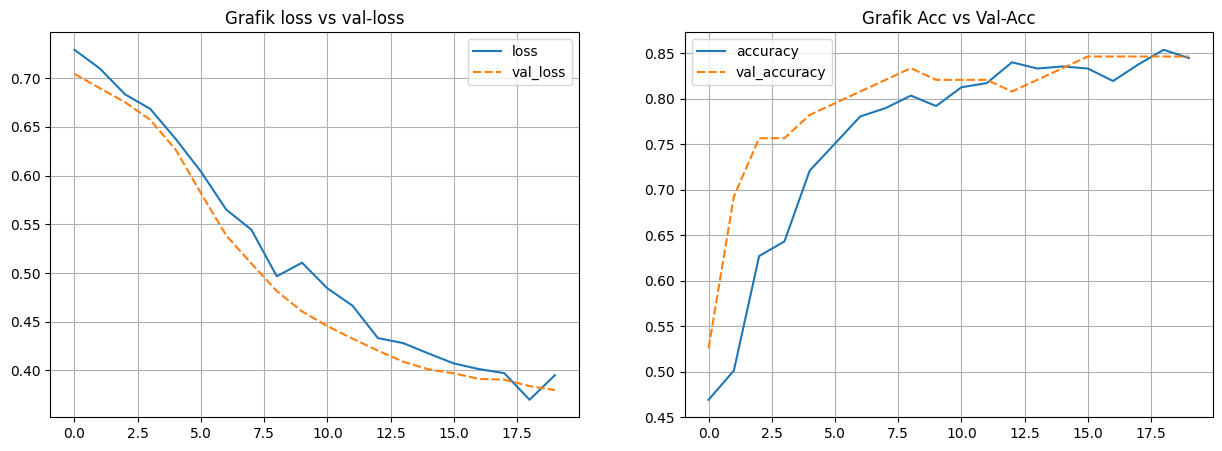

In [99]:
# Plot training result

history_sequential_df = pd.DataFrame(history_sequential.history)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_sequential_df[['loss', 'val_loss']])
plt.grid()
plt.title('Grafik loss vs val-loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_sequential_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Grafik Acc vs Val-Acc')

In [100]:
# Membuat model ANN dengan ReLU

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.initializers import HeNormal # Import HeNormal
import numpy as np

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

initializer = HeNormal(seed=seed)
loss_function = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam()

model_relu = Sequential([
  Input(shape=(135,), name='input-layer'), # Corrected input_shape from (2,) to (135,)
  Dense(5, activation='relu', kernel_initializer=initializer, name='hidden-layer-1'),
  Dropout(0.2, name= 'dropout-1'),
  Dense(5, activation='relu', kernel_initializer=initializer, name='hidden-layer-2'),
  Dropout(0.2, name= 'dropout-2'),
  Dense(1, activation="sigmoid", kernel_initializer=initializer, name='output-layer')

])

# Compile
model_relu.compile(loss=loss_function,
              optimizer=optimizer,
              metrics=['accuracy'])
model_relu.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-layer-1 (Dense)          │ (None, 5)              │           680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout-1 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-layer-2 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout-2 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output-layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 716 (2.80 KB)

 Trainable params: 716 (2.80 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
# Training Relu Model
history_relu = model_relu.fit(X_train,
                              y_train,
                              epochs=20,
                              validation_data=(X_val, y_val),
                              batch_size=10)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5355 - loss: 0.7042 - val_accuracy: 0.5513 - val_loss: 0.6998
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5767 - loss: 0.6970 - val_accuracy: 0.6026 - val_loss: 0.6882
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6430 - loss: 0.6803 - val_accuracy: 0.6538 - val_loss: 0.6769
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6613 - loss: 0.6638 - val_accuracy: 0.7051 - val_loss: 0.6619
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6842 - loss: 0.6374 - val_accuracy: 0.7179 - val_loss: 0.6416
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6934 - loss: 0.6209 - val_accuracy: 0.7051 - val_loss: 0.6191
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7300 - loss: 0.5895 - val_accuracy: 0.7179 - val_loss: 0.5905
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7506 - loss: 0.5598 - val_accuracy: 0.7179 - val_loss

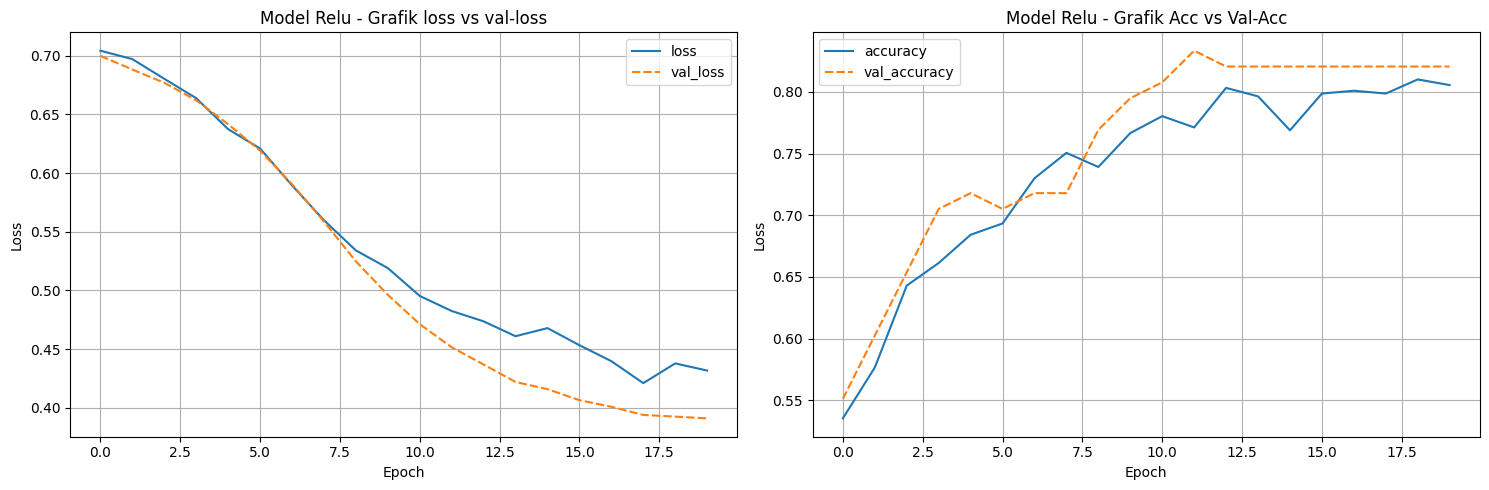

In [102]:
# Plot training result

history_relu_df = pd.DataFrame(history_relu.history)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_relu_df[['loss', 'val_loss']])
plt.grid()
plt.title('Model Relu - Grafik loss vs val-loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_relu_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Model Relu - Grafik Acc vs Val-Acc')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

  relu — Test Set Results
  Loss     : 0.4727
  Accuracy : 0.7717 (77.2%)

              precision    recall  f1-score   support

           0       0.82      0.77      0.80        53
           1       0.71      0.77      0.74        39

    accuracy                           0.77        92
   macro avg       0.77      0.77      0.77        92
weighted avg       0.78      0.77      0.77        92



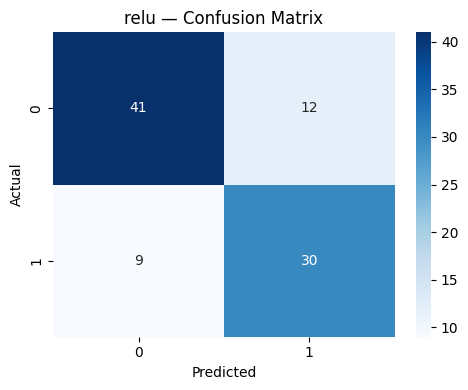

In [103]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model_eval, X_test_data, y_test_data, label="Model"):
    loss, accuracy = model_eval.evaluate(X_test_data, y_test_data, verbose=0)
    y_pred = (model_eval.predict(X_test_data, verbose=0) >= 0.5).astype(int).flatten()

    print(f"{'='*45}")
    print(f"  {label} — Test Set Results")
    print(f"{'='*45}")
    print(f"  Loss     : {loss:.4f}")
    print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)")
    print()
    print(classification_report(y_test_data, y_pred))

    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{label} — Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

# Evaluate on test set
evaluate_model(model_relu, X_test, y_test, label="relu")

In [104]:
# Menyimpan salah satu model
model_sequential.save('model_ann_terbaik.keras')

# Menyimpan pipeline
import pickle
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

# **MEMBANDINGKAN HASIL DENGAN MINI PROJECT 1**

Melalui hasil Mini Project 2 dengan menggunakan ANN sequental dan relu diatas diperoleh hasil yang mirip, sehingga saya memilih menggunakan sequental karena ukuran neutron per layer kelipatan 8 yang secara umum lebih lazim digunakan. Pada codingan diatas saya juga menggunakan sistem stopping dalam menjalankan model sehingga model akan berhenti jika sudah sempurna dan menghindari overfitting.

Pada Miniproject 1 saya menggunakan Random Forest dan Linear Regression. Walaupun pada bagian Linear Regression saya sudah menmberikan alpha dengan kategori bermacam-macam tetapi model mengalami overfitting.

Alhasil, ketika dibandingkan antara kedua model dapat ditarik kesimpulan bahwa Mini Project 2 dengan menggunakan ANN sequental jauh lebih baik. Hal ini tidak dapat terlepas dengan batasan stop epoch yang akan berhenti saat model sudah mencapai titik sempurna dan terhindar overfitting.